In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Configuración estética global para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Por favor, selecciona y sube tu archivo único de Excel (.xlsx):")
uploaded = files.upload()

# Detectamos automáticamente el nombre del archivo que subiste
nombre_archivo_excel = list(uploaded.keys())[0]
print(f"\n✅ Archivo cargado con éxito: {nombre_archivo_excel}")

Por favor, selecciona y sube tu archivo único de Excel (.xlsx):


Saving Linear ECG.xlsx to Linear ECG (1).xlsx

✅ Archivo cargado con éxito: Linear ECG (1).xlsx


In [5]:
# Mapeo del nombre exacto de la HOJA (pestaña) a la etiqueta que queremos en el gráfico
hojas_condiciones = {
    'Control SC1': 'Control_SC1',
    'EO': 'EO',
    'AC1': 'AC1',
    'AC2': 'AC2',
    'AC3': 'AC3',
    'AC4': 'AC4'
}

lista_df = []

# Iteramos sobre cada hoja del mismo archivo de Excel
for nombre_hoja, etiqueta_condicion in hojas_condiciones.items():
    try:
        # Usamos pd.read_excel especificando el parámetro sheet_name
        df = pd.read_excel(nombre_archivo_excel, sheet_name=nombre_hoja)

        # Agregamos la columna para identificar la fase del experimento
        df['Condition'] = etiqueta_condicion
        lista_df.append(df)
        print(f"✅ Hoja '{nombre_hoja}' procesada e integrada.")

    except Exception as e:
        print(f"❌ Error al leer la hoja '{nombre_hoja}'. Revisa si el nombre en el Excel es exacto. Detalle: {e}")

# Consolidamos todo en un único DataFrame si se lograron leer las hojas
if lista_df:
    df_total = pd.concat(lista_df, ignore_index=True)
    print(f"\n¡Éxito! Dataset consolidado desde el archivo de Excel.")
    print(f"Filas totales combinadas: {df_total.shape[0]} | Columnas: {df_total.shape[1]}")
else:
    print("❌ No se pudo cargar ninguna hoja. Verifica el archivo de Excel.")

✅ Hoja 'Control SC1' procesada e integrada.
✅ Hoja 'EO' procesada e integrada.
✅ Hoja 'AC1' procesada e integrada.
✅ Hoja 'AC2' procesada e integrada.
✅ Hoja 'AC3' procesada e integrada.
✅ Hoja 'AC4' procesada e integrada.

¡Éxito! Dataset consolidado desde el archivo de Excel.
Filas totales combinadas: 383 | Columnas: 15


In [6]:
print("--- 1. Verificación de Valores Nulos ---")
print(df_total.isnull().sum())

print("\n--- 2. Resumen Estadístico de las Métricas Cardíacas ---")
# Transponemos (.T) para que sea mucho más cómodo de leer en pantalla
display(df_total.describe().T)

--- 1. Verificación de Valores Nulos ---
Subject NO.           0
Gender                0
Menstrual cycles    121
Mean HR (BPM)         5
AVNN (ms)             5
SDNN (ms)             5
NN50 (beats)          5
pNN50 (%)             5
RMSSD (ms)            5
LF (ms2)              5
LF Norm (n.u.)        5
HF (ms2)              5
HF Norm (n.u.)        5
LF/HF Ratio           5
Condition             0
dtype: int64

--- 2. Resumen Estadístico de las Métricas Cardíacas ---


,count,mean,std,min,25%,50%,75%,max
Subject NO.,383.0,39.326371,22.208567,1.0000,19.500000,39.00000,57.000000,77.0000
Mean HR (BPM),378.0,79.888113,11.753950,51.2243,73.068900,79.36645,86.681100,109.3391
AVNN (ms),378.0,767.846554,116.854109,548.7514,692.193175,755.98730,821.142525,1171.3195
SDNN (ms),378.0,39.612325,21.466748,8.9673,27.363200,37.22270,45.998125,171.3523
NN50 (beats),378.0,81.584656,68.379728,0.0000,19.000000,77.50000,127.000000,285.0000
pNN50 (%),378.0,21.636671,19.629575,0.0000,4.247175,17.98755,33.810275,82.4451
RMSSD (ms),378.0,41.778793,30.255740,6.7660,25.560100,37.10325,49.439650,249.9798
LF (ms2),378.0,660.509279,713.734606,23.0689,243.791800,423.82960,838.188000,5528.7950
LF Norm (n.u.),378.0,49.017099,18.226239,2.7481,35.695775,49.55540,63.205200,91.4926
HF (ms2),378.0,1028.402471,2593.601245,16.2398,194.065800,543.50235,955.597150,27433.2200


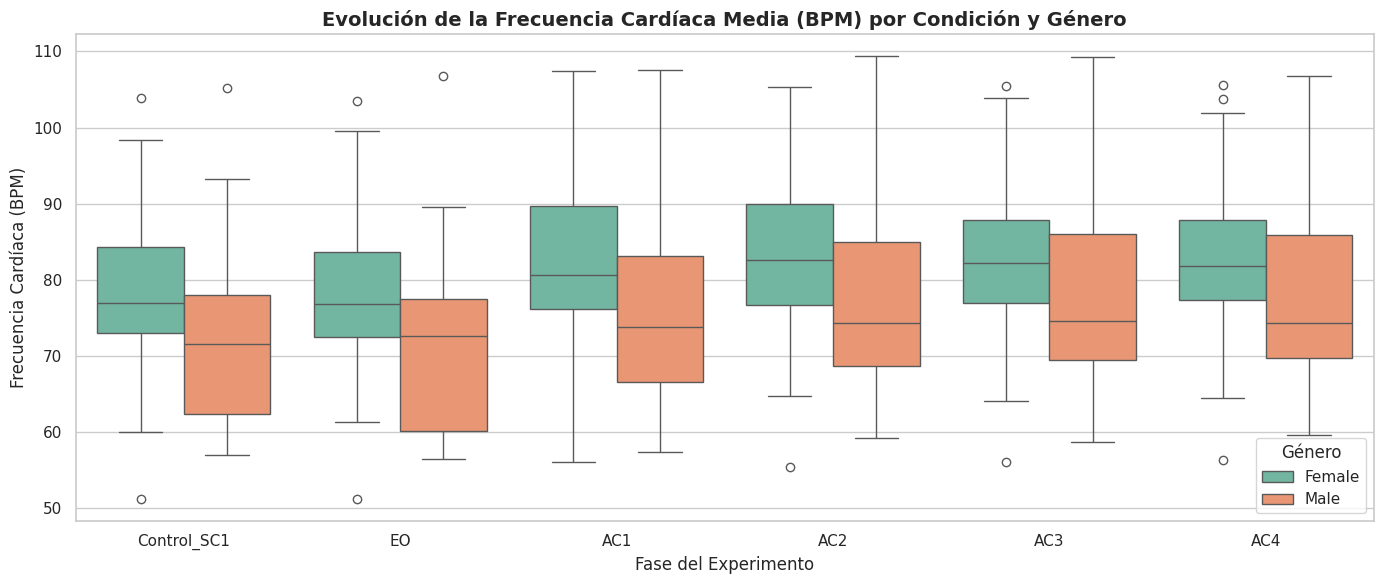

In [12]:
plt.figure(figsize=(14, 6))

# 1. Definimos el orden lógico del experimento
orden_fases = ['Control_SC1', 'EO', 'AC1', 'AC2', 'AC3', 'AC4']

# 2. Convertimos la columna a categoría ordenada para que 'lineplot' y 'boxplot' la respeten automáticamente
df_total['Condition'] = pd.Categorical(df_total['Condition'], categories=orden_fases, ordered=True)

# 3. Dibujamos el Boxplot separado por Género (hue='Gender')
sns.boxplot(data=df_total, x='Condition', y='Mean HR (BPM)', hue='Gender', palette='Set2')



# Configuraciones de etiquetas y títulos
plt.title('Evolución de la Frecuencia Cardíaca Media (BPM) por Condición y Género', fontsize=14, fontweight='bold')
plt.xlabel('Fase del Experimento', fontsize=12)
plt.ylabel('Frecuencia Cardíaca (BPM)', fontsize=12)
plt.legend(title='Género')

plt.tight_layout()
plt.show()

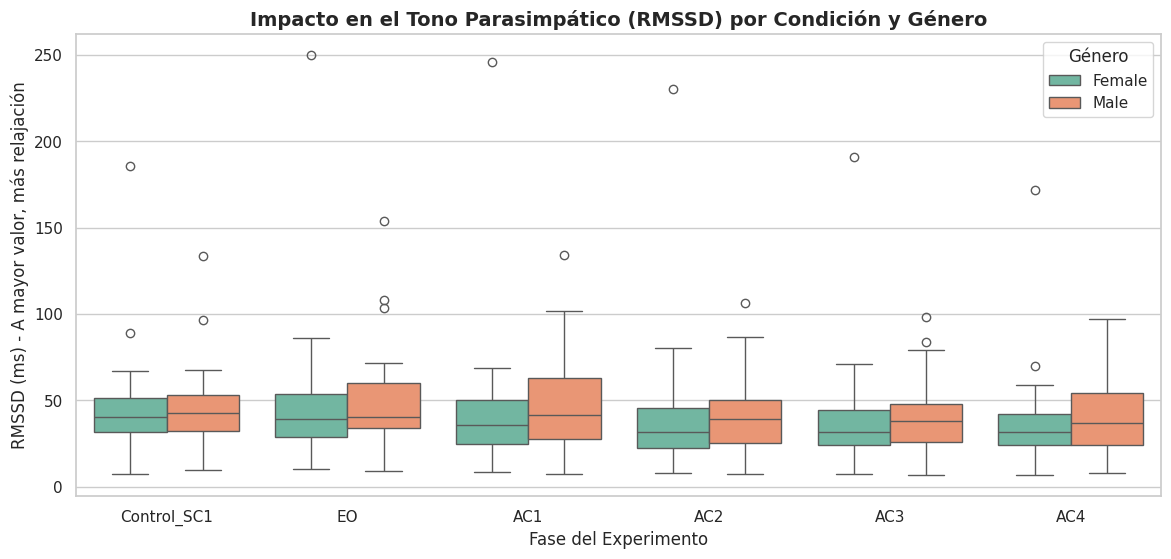

In [8]:
plt.figure(figsize=(14, 6))

# Boxplot comparativo por Género
sns.boxplot(data=df_total, x='Condition', y='RMSSD (ms)', hue='Gender', order=orden_fases, palette='Set2')

plt.title('Impacto en el Tono Parasimpático (RMSSD) por Condición y Género', fontsize=14, fontweight='bold')
plt.xlabel('Fase del Experimento', fontsize=12)
plt.ylabel('RMSSD (ms) - A mayor valor, más relajación', fontsize=12)
plt.legend(title='Género')
plt.show()

/tmp/ipykernel_6222/138094925.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_total, x='Condition', y='LF/HF Ratio', order=orden_fases, palette='Purples', inner='quart')


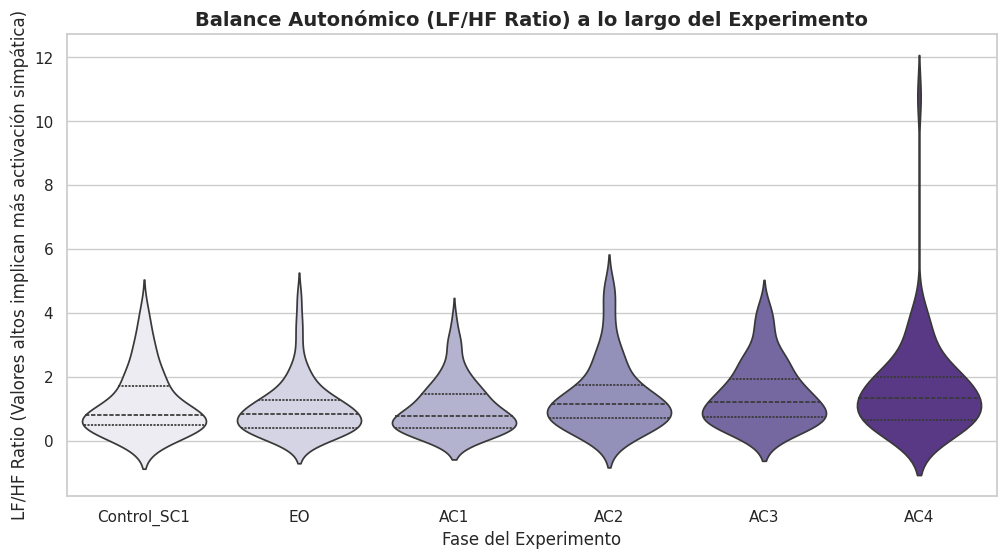

In [14]:
plt.figure(figsize=(12, 6))

# Usamos un violinplot para ver no solo los cuartiles, sino también la densidad de los datos
sns.violinplot(data=df_total, x='Condition', y='LF/HF Ratio', order=orden_fases, palette='Purples', inner='quart')

plt.title('Balance Autonómico (LF/HF Ratio) a lo largo del Experimento', fontsize=14, fontweight='bold')
plt.xlabel('Fase del Experimento', fontsize=12)
plt.ylabel('LF/HF Ratio (Valores altos implican más activación simpática)', fontsize=12)

# Si tienes valores atípicos (outliers) muy extremos que arruinan la escala, desmarca la siguiente línea:
# plt.ylim(0, df_total['LF/HF Ratio'].quantile(0.95))

plt.show()

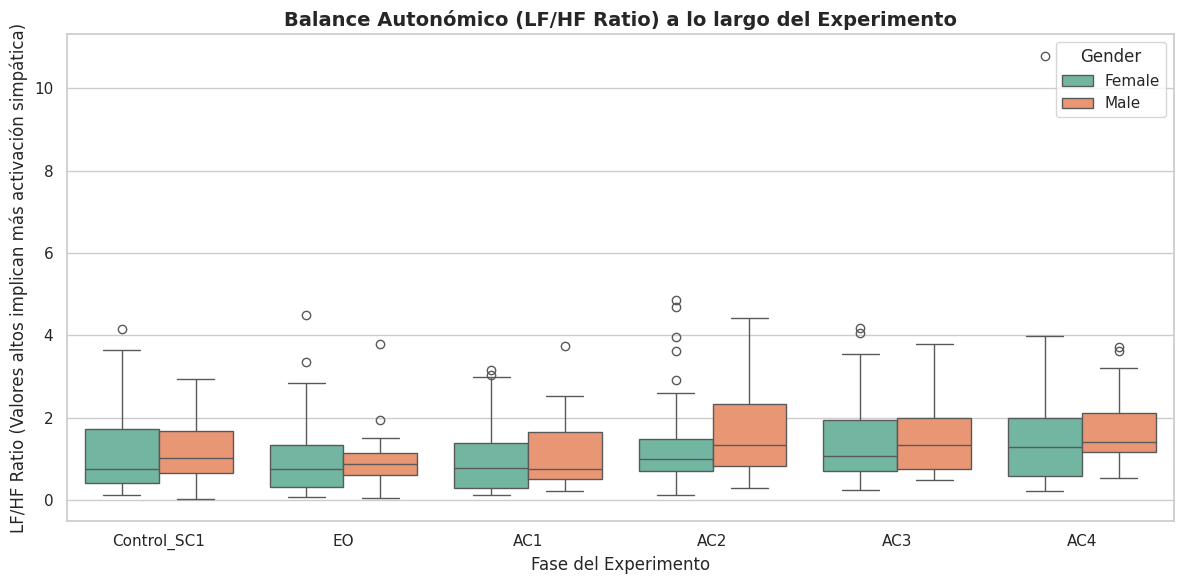

In [16]:
plt.figure(figsize=(12, 6))

# Cambiamos violinplot por boxplot y ajustamos los parámetros para evitar advertencias
sns.boxplot(data=df_total, x='Condition', y='LF/HF Ratio', hue='Gender', palette='Set2')

plt.title('Balance Autonómico (LF/HF Ratio) a lo largo del Experimento', fontsize=14, fontweight='bold')
plt.xlabel('Fase del Experimento', fontsize=12)
plt.ylabel('LF/HF Ratio (Valores altos implican más activación simpática)', fontsize=12)

# NOTA: El balance LF/HF suele tener picos muy altos (outliers).
# Si el gráfico se ve muy aplastado por culpa de algunos valores extremos,
# desmarca la siguiente línea borrando el '#' para recortar el eje Y al percentil 95:
# plt.ylim(0, df_total['LF/HF Ratio'].quantile(0.95))

plt.tight_layout()
plt.show()

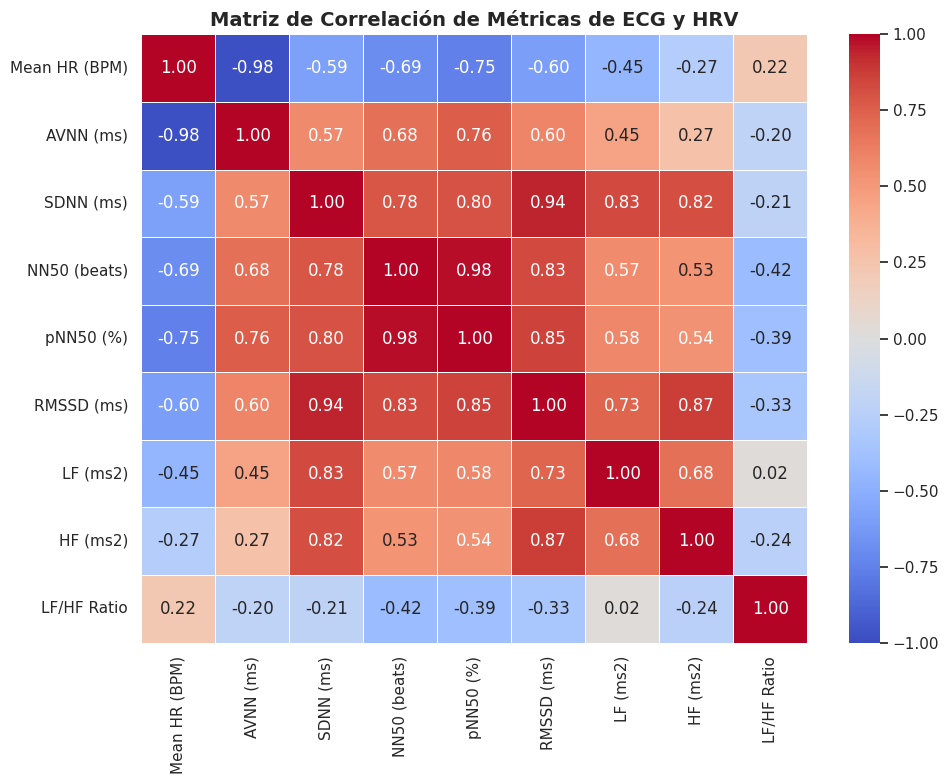

In [10]:
# Seleccionamos solo las columnas numéricas principales de HRV
columnas_interes = [
    'Mean HR (BPM)', 'AVNN (ms)', 'SDNN (ms)', 'NN50 (beats)',
    'pNN50 (%)', 'RMSSD (ms)', 'LF (ms2)', 'HF (ms2)', 'LF/HF Ratio'
]

plt.figure(figsize=(10, 8))
matriz_corr = df_total[columnas_interes].corr()

# Dibujamos el mapa de calor
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Matriz de Correlación de Métricas de ECG y HRV', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()